## New personas creation based on behaviour

In [1]:
from social_graph.analysis import *
from social_graph.pipeline import *
from social_graph.metrics import *

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\magda\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [2]:
conn3 = sqlite3.connect("data/exp_set_1/database_server_3.db")
conn4 = sqlite3.connect("data/exp_set_1/database_server_4.db")
conn5 = sqlite3.connect("data/exp_set_1/database_server_5.db")

connb1 = sqlite3.connect("data/exp_set_1/database_server_b1.db")
connb2 = sqlite3.connect("data/exp_set_1/database_server_b2.db")
connb3 = sqlite3.connect("data/exp_set_1/database_server_b3.db")

In [3]:
conn3 = sqlite3.connect("data/exp_set_2/database_server.db")

In [4]:
persona_df = pd.read_csv('data/exp_set_1/persona_df.csv')
persona_df.head()

,Unnamed: 0,id,openness,conscientiousness,extroversion,agreeableness,neuroticism,age,profession,gender,leaning,education_level,persona
0,1,2,consistent/cautious,efficient/organized,solitary/reserved,friendly/compassionate,resilient/confident,young,Skilled_Trades,female,democrat,master,Persona_2
1,2,3,inventive/curious,efficient/organized,outgoing/energetic,friendly/compassionate,sensitive/nervous,old,Skilled_Trades,male,democrat,master,Persona_3
2,3,4,inventive/curious,extravagant/careless,outgoing/energetic,critical/judgmental,sensitive/nervous,young,Science_Academia,female,democrat,master,Persona_4
3,4,5,consistent/cautious,extravagant/careless,solitary/reserved,critical/judgmental,resilient/confident,old,Security,male,democrat,master,Persona_2
4,5,6,consistent/cautious,extravagant/careless,solitary/reserved,friendly/compassionate,sensitive/nervous,old,Science_Academia,male,democrat,master,Persona_3


Data loading ...

Number of users: 1000
Total actions: 20653
Follow actions: 19661
Unfollow actions: 992
Number of rounds: 51
Number of posts: 194066

Checking professions consistency ...

Number of professions not in map: 0
Professions: set()

Creating persona and features DataFrames ...

Features encoded size: (1000, 10)

Searching best number of persona ...

k=2 silhouette=0.1720
k=3 silhouette=0.1729
k=4 silhouette=0.2169
k=5 silhouette=0.2234
k=6 silhouette=0.2516
k=7 silhouette=0.2478
k=8 silhouette=0.2728
k=9 silhouette=0.3159


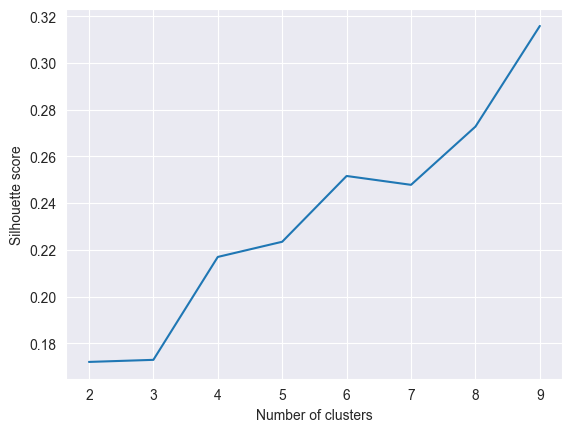


Done!


In [5]:
features_cols = ['openness', 'conscientiousness', 'extroversion', 'agreeableness', 'neuroticism']
persona_df, features, follow = run_simulation_preprocessing(conn3, feature_cols=features_cols)

In [6]:
persona_df = create_personae(6, persona_df, features)

persona
Persona_1    234
Persona_2    186
Persona_6    158
Persona_3    156
Persona_4    150
Persona_5    116
Name: count, dtype: int64


In [7]:
personas = persona_df[['id', 'persona']].rename(columns={'id': 'follower_id'})
personas.head()

,follower_id,persona
1,2,Persona_6
2,3,Persona_5
3,4,Persona_1
4,5,Persona_3
5,6,Persona_6


In [8]:
follow = pd.read_sql("SELECT * FROM follow", conn3)
follow = follow.merge(personas, on='follower_id', how='left')
follow.head()

,user_id,follower_id,id,action,round,persona
0,744,856,1,follow,1,Persona_4
1,27,80,2,follow,1,Persona_6
2,529,27,3,follow,1,Persona_1
3,872,911,4,follow,1,Persona_2
4,249,872,5,follow,1,Persona_4


#### Lifespan

In [9]:
lifespan = lifespan_analysis(follow, agg_by='follower_id')
lifespan.head()

Invalid unfollow action for users 67 -> 216: unfollow
Invalid unfollow action for users 118 -> 758: unfollow
Invalid unfollow action for users 118 -> 905: unfollow
Invalid unfollow action for users 123 -> 774: unfollow
Invalid unfollow action for users 249 -> 178: unfollow
Invalid unfollow action for users 249 -> 178: unfollow
Invalid unfollow action for users 249 -> 178: unfollow
Invalid unfollow action for users 249 -> 178: unfollow
Invalid unfollow action for users 275 -> 708: unfollow
Invalid unfollow action for users 330 -> 847: unfollow
Invalid unfollow action for users 342 -> 587: unfollow
Invalid unfollow action for users 342 -> 587: unfollow
Invalid unfollow action for users 343 -> 845: unfollow
Invalid unfollow action for users 354 -> 342: unfollow
Invalid unfollow action for users 356 -> 587: unfollow
Invalid unfollow action for users 359 -> 331: unfollow
Invalid unfollow action for users 438 -> 342: unfollow
Invalid unfollow action for users 438 -> 342: unfollow
Invalid unf

,follower_id,total_connections,existing,removed,lifespan_mean,lifespan_std,lifespan_median,survival_rate
0,2,13,13,0,NaN,NaN,NaN,1.000000
1,3,4,4,0,NaN,NaN,NaN,1.000000
2,4,20,20,0,NaN,NaN,NaN,1.000000
3,5,139,130,9,13.319444,18.333558,1.375000,0.935252
4,6,32,30,2,1.020833,1.443676,1.020833,0.937500


Why it's only 818 rows while e.g. there's 877 nodes in the largest connective component???

#### Follows

In [10]:
G, G_lcc = create_graph(follow)
local_metrics, summary = calculate_local_metrics(G_lcc)

Number of nodes: 983
Number of edges: 18691
Number of connective components: 3
Components sizes: [981, 1, 1]
Number of nodes (LCC): 981
Number of edges (LCC): 18691


In [11]:
local_metrics.drop(columns=['persona'], inplace=True)
local_metrics.head()

,node,in_degree,out_degree,total_degree,betweenness,eigenvector,pagerank,kcore
0,856,141,114,255,0.016564,0.110036,0.006396,41
1,744,154,143,297,0.024440,0.124465,0.007169,41
2,80,51,53,104,0.004106,0.059890,0.002546,41
3,27,104,102,206,0.014151,0.092359,0.004663,41
4,529,109,99,208,0.013711,0.096607,0.004975,41


In [12]:
len(local_metrics[local_metrics['out_degree'] == 0])

27

In [13]:
len(lifespan[lifespan['existing'] == 0])

1

877 - 72 == 818 - 13 so in lifespan table there are only users who have followed any user.

<Axes: >

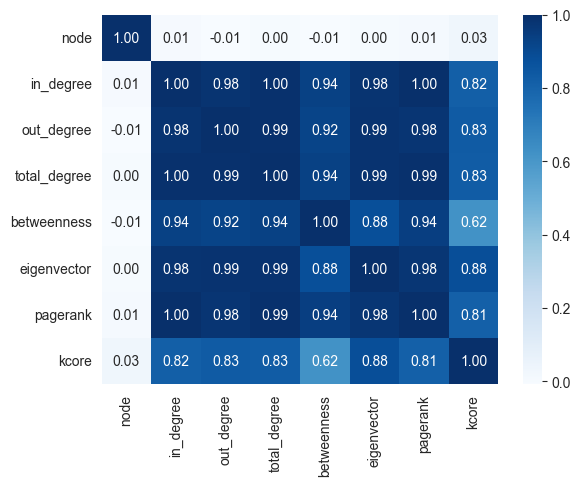

In [14]:
corr = local_metrics.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues')

Most of structural metrics is highly correlated. We will keep betweenness and kcore. On the degree-related metrics we will build new features.

#### Posts

In [15]:
posts = pd.read_sql("SELECT * FROM post", conn3)
personas.rename(columns={'follower_id': 'user_id'}, inplace=True)
posts = posts.merge(personas, on='user_id', how='left')
posts.head()

,id,tweet,post_img,user_id,comment_to,thread_id,round,news_id,shared_from,image_id,reaction_count,persona
0,1,Just finished bingewatching a new series on Ne...,None,961,-1,1,1,None,-1,None,0,Persona_1
1,2,Nothing beats that postworkout feeling! 💪 Just...,None,856,-1,2,1,None,-1,None,0,Persona_4
2,3,Nothing beats that postworkout feeling! 💪 Just...,None,856,-1,3,1,None,-1,None,0,Persona_4
3,4,Nothing beats that postworkout feeling! 💪 Just...,None,856,-1,4,1,None,-1,None,1,Persona_4
4,5,Nothing beats that postworkout feeling! 💪 Just...,None,856,-1,5,1,None,-1,None,2,Persona_4


In [16]:
posts.groupby(['user_id', 'round'])['tweet'].size().head()

user_id  round
2        81       5
         166      4
         249      4
         260      6
         273      9
Name: tweet, dtype: int64

Somehow there is a lot of duplicates

In [17]:
dup = posts[
    posts.duplicated(
        subset=['user_id', 'tweet', 'round'],
        keep=False
    )
].sort_values(['user_id', 'round'])

dup.head(20)

,id,tweet,post_img,user_id,comment_to,thread_id,round,news_id,shared_from,image_id,reaction_count,persona
40518,40519,nothing beats that first sip of iced coffee be...,None,2,-1,40519,260,None,-1,None,0,Persona_6
40519,40520,nothing beats that first sip of iced coffee be...,None,2,-1,40520,260,None,-1,None,0,Persona_6
42495,42496,literally cannot start my day without a huge i...,None,2,-1,42496,273,None,-1,None,0,Persona_6
42497,42498,literally cannot start my day without a huge i...,None,2,-1,42498,273,None,-1,None,0,Persona_6
42499,42500,nothing beats that first sip of iced coffee be...,None,2,-1,42500,273,None,-1,None,0,Persona_6
42500,42501,nothing beats that first sip of iced coffee be...,None,2,-1,42501,273,None,-1,None,0,Persona_6
42501,42502,nothing beats that first sip of iced coffee be...,None,2,-1,42502,273,None,-1,None,0,Persona_6
42502,42503,nothing beats that first sip of iced coffee be...,None,2,-1,42503,273,None,-1,None,0,Persona_6
50613,50614,nothing beats that first sip of iced coffee be...,None,2,-1,50614,325,None,-1,None,0,Persona_6
50615,50616,nothing beats that first sip of iced coffee be...,None,2,-1,50616,325,None,-1,None,0,Persona_6


In [18]:
len(dup)

58246

In [19]:
posts = posts.drop_duplicates(
    subset=['user_id', 'tweet', 'round']
)
len(posts)

155568

In [20]:
posts_summary = posts_analysis(posts)
posts_summary.head()

,user_id,positive_posts,neutral_posts,negative_posts,total_posts,avg_word_count,persona
0,2,70,0,15,85,25.094118,Persona_6
1,3,22,1,0,23,30.956522,Persona_5
2,4,75,1,2,78,29.038462,Persona_1
3,5,1038,58,69,1165,26.466953,Persona_3
4,6,153,20,25,198,24.606061,Persona_6


## New personas

In [21]:
local_metrics.rename(columns={'node': 'user_id'}, inplace=True)
lifespan.rename(columns={'follower_id': 'user_id'}, inplace=True)

personas_features = (lifespan.
               merge(local_metrics, on='user_id').
               merge(posts_summary, on='user_id'))

personas_features.head()

,user_id,total_connections,existing,removed,lifespan_mean,lifespan_std,lifespan_median,survival_rate,in_degree,out_degree,...,betweenness,eigenvector,pagerank,kcore,positive_posts,neutral_posts,negative_posts,total_posts,avg_word_count,persona
0,2,13,13,0,NaN,NaN,NaN,1.000000,12,13,...,5.842536e-05,0.015870,0.000672,19,70,0,15,85,25.094118,Persona_6
1,3,4,4,0,NaN,NaN,NaN,1.000000,1,4,...,4.417667e-07,0.004818,0.000194,5,22,1,0,23,30.956522,Persona_5
2,4,20,20,0,NaN,NaN,NaN,1.000000,7,20,...,1.648232e-04,0.015062,0.000478,19,75,1,2,78,29.038462,Persona_1
3,5,139,130,9,13.319444,18.333558,1.375000,0.935252,130,130,...,2.151160e-02,0.107608,0.005960,41,1038,58,69,1165,26.466953,Persona_3
4,6,32,30,2,1.020833,1.443676,1.020833,0.937500,21,30,...,3.493630e-03,0.025537,0.001311,27,153,20,25,198,24.606061,Persona_6


810 rows ????

In [22]:
personas_features.describe()

,user_id,total_connections,existing,removed,lifespan_mean,lifespan_std,lifespan_median,survival_rate,in_degree,out_degree,total_degree,betweenness,eigenvector,pagerank,kcore,positive_posts,neutral_posts,negative_posts,total_posts,avg_word_count
count,954.000000,954.000000,954.000000,954.000000,277.000000,151.000000,277.000000,954.000000,954.000000,954.000000,954.000000,954.000000,954.000000,954.000000,954.000000,954.000000,954.000000,954.000000,954.000000,954.000000
mean,503.042977,20.581761,19.592243,0.989518,5.487961,8.074211,4.106197,0.976273,19.548218,19.592243,39.140461,0.001689,0.019469,0.001042,16.808176,134.886792,9.629979,18.145702,162.662474,28.885033
std,287.869059,29.534836,27.202293,2.677467,7.210233,6.770040,6.782938,0.052879,29.311768,27.202293,56.241806,0.004188,0.025881,0.001314,12.770305,240.028080,22.077522,37.728844,289.019835,3.512864
min,2.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.333333,0.000000,1.000000,1.000000,0.000000,0.000026,0.000158,1.000000,2.000000,0.000000,0.000000,3.000000,19.666667
25%,256.250000,4.000000,4.000000,0.000000,0.000000,1.144952,0.000000,0.967994,3.000000,4.000000,8.000000,0.000026,0.003663,0.000305,6.000000,22.000000,0.000000,2.000000,26.000000,26.571014
50%,502.500000,9.000000,9.000000,0.000000,2.062500,8.028476,1.062500,1.000000,8.000000,9.000000,17.000000,0.000181,0.008739,0.000530,13.000000,49.000000,2.000000,5.000000,57.000000,28.758648
75%,748.750000,22.000000,21.000000,1.000000,9.041667,12.834351,4.916667,1.000000,21.750000,21.000000,43.000000,0.001194,0.023829,0.001123,26.000000,124.000000,8.000000,16.000000,158.750000,31.000000
max,1001.000000,180.000000,154.000000,26.000000,36.645833,25.337993,36.520833,1.000000,174.000000,154.000000,324.000000,0.035258,0.126108,0.008087,41.000000,1855.000000,223.000000,340.000000,2153.000000,45.500000


### Feature engineering

In [23]:
days = 60

In [24]:
posts_columns = ['positive_posts', 'neutral_posts', 'negative_posts']

for column in posts_columns:
    personas_features[column + '_ratio'] = personas_features[column] / personas_features['total_posts']

personas_features['posts_per_day'] = personas_features['total_posts'] / days

In [25]:
personas_features['in_out_degree_ratio'] = personas_features['in_degree'] / (personas_features['out_degree'] + 1)

In [26]:
personas_features.head()

,user_id,total_connections,existing,removed,lifespan_mean,lifespan_std,lifespan_median,survival_rate,in_degree,out_degree,...,neutral_posts,negative_posts,total_posts,avg_word_count,persona,positive_posts_ratio,neutral_posts_ratio,negative_posts_ratio,posts_per_day,in_out_degree_ratio
0,2,13,13,0,NaN,NaN,NaN,1.000000,12,13,...,0,15,85,25.094118,Persona_6,0.823529,0.000000,0.176471,1.416667,0.857143
1,3,4,4,0,NaN,NaN,NaN,1.000000,1,4,...,1,0,23,30.956522,Persona_5,0.956522,0.043478,0.000000,0.383333,0.200000
2,4,20,20,0,NaN,NaN,NaN,1.000000,7,20,...,1,2,78,29.038462,Persona_1,0.961538,0.012821,0.025641,1.300000,0.333333
3,5,139,130,9,13.319444,18.333558,1.375000,0.935252,130,130,...,58,69,1165,26.466953,Persona_3,0.890987,0.049785,0.059227,19.416667,0.992366
4,6,32,30,2,1.020833,1.443676,1.020833,0.937500,21,30,...,20,25,198,24.606061,Persona_6,0.772727,0.101010,0.126263,3.300000,0.677419


In [27]:
selected_features = personas_features[['user_id', 'persona', 'in_out_degree_ratio', 'betweenness', 'kcore',
                    'neutral_posts_ratio', 'negative_posts_ratio', 'posts_per_day', 'lifespan_median', 'survival_rate', 'avg_word_count']]

selected_features.set_index('user_id', inplace=True)
selected_features.head()

,persona,in_out_degree_ratio,betweenness,kcore,neutral_posts_ratio,negative_posts_ratio,posts_per_day,lifespan_median,survival_rate,avg_word_count
user_id,,,,,,,,,,
2,Persona_6,0.857143,5.842536e-05,19,0.000000,0.176471,1.416667,NaN,1.000000,25.094118
3,Persona_5,0.200000,4.417667e-07,5,0.043478,0.000000,0.383333,NaN,1.000000,30.956522
4,Persona_1,0.333333,1.648232e-04,19,0.012821,0.025641,1.300000,NaN,1.000000,29.038462
5,Persona_3,0.992366,2.151160e-02,41,0.049785,0.059227,19.416667,1.375000,0.935252,26.466953
6,Persona_6,0.677419,3.493630e-03,27,0.101010,0.126263,3.300000,1.020833,0.937500,24.606061


Handle skew - Apply log to heavy-tailed features.

In [28]:
selected_features['posts_per_day'] = np.log1p(selected_features['posts_per_day'])
# selected_features['total_degree'] = np.log1p(selected_features['total_degree'])
selected_features['betweenness'] = np.log1p(selected_features['betweenness'])
selected_features['lifespan_median'].fillna(0, inplace=True)

C:\Users\magda\AppData\Local\Temp\ipykernel_26484\1448811988.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_features['posts_per_day'] = np.log1p(selected_features['posts_per_day'])
C:\Users\magda\AppData\Local\Temp\ipykernel_26484\1448811988.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_features['betweenness'] = np.log1p(selected_features['betweenness'])
C:\Users\magda\AppData\Local\Temp\ipykernel_26484\1448811988.py:4: FutureWarning: A value is trying to be set on a copy of a D

<Axes: >

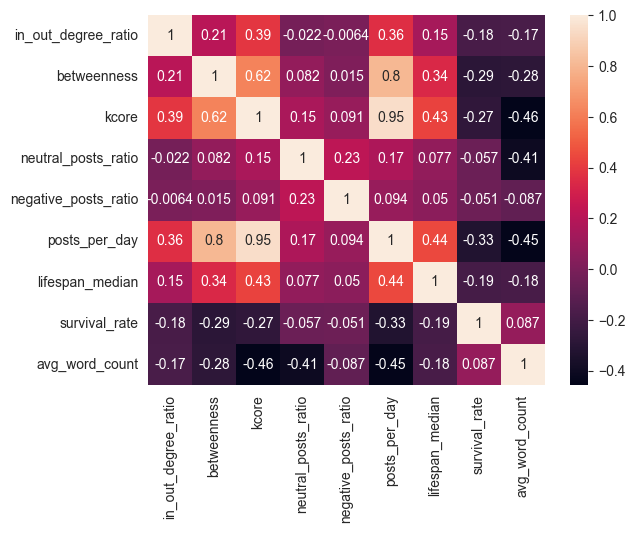

In [29]:
corr = selected_features.drop(columns=['persona'], inplace=False).corr()
sns.heatmap(corr, annot=True, cmap='Blues')

We keep these features.

In [30]:
from sklearn.preprocessing import StandardScaler

features_scaled = selected_features.copy().drop(columns=['persona'])

# Fill Nan in lifespan_median with zeros.
features_scaled['lifespan_median'].fillna(0, inplace=True)

features_scaled = StandardScaler().fit_transform(features_scaled)

C:\Users\magda\AppData\Local\Temp\ipykernel_26484\4142756251.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  features_scaled['lifespan_median'].fillna(0, inplace=True)


### Clustering

#### KMeans

k=2 silhouette=0.3369
k=3 silhouette=0.2196
k=4 silhouette=0.2131
k=5 silhouette=0.2314
k=6 silhouette=0.2138
k=7 silhouette=0.1958
k=8 silhouette=0.2012
k=9 silhouette=0.1925


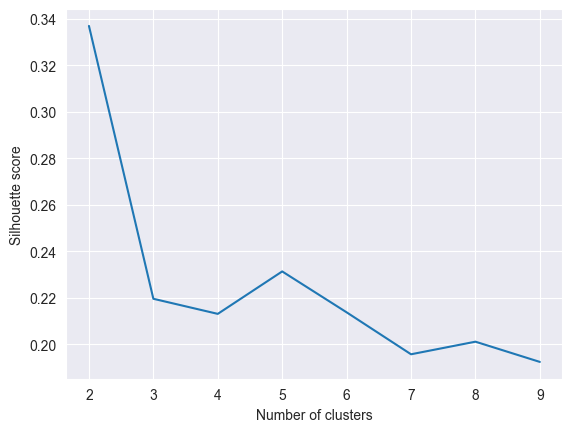

In [31]:
search_best_number_of_personae(features_scaled)

Although the silhouette score is maximized at k=2, this solution yields overly coarse clusters that obscure meaningful behavioral distinctions. Solutions with k=3 and k=4 provide slightly lower silhouette values but reveal richer and more interpretable structure, including distinct groups of highly central actors, stable core users, and peripheral participants. Therefore, k=4 is selected as a balance between cluster quality and interpretability.

In [32]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=6, random_state=42)
labels = kmeans.fit_predict(features_scaled)

In [33]:
selected_features['kmeans_label'] = labels
selected_features.head()

C:\Users\magda\AppData\Local\Temp\ipykernel_26484\499104692.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_features['kmeans_label'] = labels


,persona,in_out_degree_ratio,betweenness,kcore,neutral_posts_ratio,negative_posts_ratio,posts_per_day,lifespan_median,survival_rate,avg_word_count,kmeans_label
user_id,,,,,,,,,,,
2,Persona_6,0.857143,5.842365e-05,19,0.000000,0.176471,0.882389,0.000000,1.000000,25.094118,0
3,Persona_5,0.200000,4.417666e-07,5,0.043478,0.000000,0.324496,0.000000,1.000000,30.956522,3
4,Persona_1,0.333333,1.648096e-04,19,0.012821,0.025641,0.832909,0.000000,1.000000,29.038462,3
5,Persona_3,0.992366,2.128349e-02,41,0.049785,0.059227,3.016352,1.375000,0.935252,26.466953,2
6,Persona_6,0.677419,3.487541e-03,27,0.101010,0.126263,1.458615,1.020833,0.937500,24.606061,4


In [34]:
selected_features['kmeans_label'].value_counts()

kmeans_label
3    363
0    213
4    151
1    143
2     51
5     33
Name: count, dtype: int64

In [35]:
selected_features.drop(columns=['kmeans_label'], inplace=False).groupby('persona').mean()

,in_out_degree_ratio,betweenness,kcore,neutral_posts_ratio,negative_posts_ratio,posts_per_day,lifespan_median,survival_rate,avg_word_count
persona,,,,,,,,,
Persona_1,0.841252,0.001417,16.986239,0.055433,0.120497,0.917540,1.060589,0.979509,28.656576
Persona_2,0.861952,0.001508,15.895028,0.034730,0.112633,0.846011,0.919429,0.975123,30.148221
Persona_3,0.866491,0.002402,18.780000,0.028364,0.067079,1.050172,1.526389,0.972730,29.532069
Persona_4,0.834807,0.001645,15.958904,0.031075,0.070499,0.859982,1.414954,0.982293,29.731819
Persona_5,0.737688,0.001466,16.372727,0.067797,0.087171,0.907954,0.879735,0.977436,26.263508
Persona_6,0.755675,0.001731,16.825503,0.075590,0.152222,0.950567,1.392478,0.969745,28.139047


In [36]:
for col in selected_features.drop(columns=['kmeans_label','persona'], inplace=False):
    groups = [
        selected_features[selected_features['persona'] == p][col]
        for p in selected_features['persona'].unique()
    ]

    stat_diff = kruskal(*groups)
    print(f"{col} statistics: p = {stat_diff.pvalue:.4f}")

in_out_degree_ratio statistics: p = 0.0193
betweenness statistics: p = 0.3907
kcore statistics: p = 0.3250
neutral_posts_ratio statistics: p = 0.0000
negative_posts_ratio statistics: p = 0.0000
posts_per_day statistics: p = 0.2961
lifespan_median statistics: p = 0.1348
survival_rate statistics: p = 0.2465
avg_word_count statistics: p = 0.0000


In [37]:
selected_features.drop(columns=['persona'], inplace=False).groupby('kmeans_label').mean()

,in_out_degree_ratio,betweenness,kcore,neutral_posts_ratio,negative_posts_ratio,posts_per_day,lifespan_median,survival_rate,avg_word_count
kmeans_label,,,,,,,,,
0,1.199493,0.000511,14.483568,0.032060,0.087832,0.746659,0.219777,0.951063,29.353481
1,0.682421,0.000341,12.146853,0.124939,0.176675,0.666985,0.077506,0.992968,26.436972
2,1.070016,0.016609,41.000000,0.064982,0.099644,2.967019,4.987337,0.920244,25.676267
3,0.535330,0.000152,7.548209,0.019707,0.077372,0.408068,0.006772,0.999023,30.982091
4,0.984891,0.002780,34.503311,0.056684,0.119237,1.729898,1.119619,0.965227,27.018970
5,1.039710,0.003696,35.515152,0.065472,0.125271,1.898972,19.807449,0.953537,26.899690


**Comment:**
- New clusters are much more structured, old personas look almost flat/random.
- old personas are very similar across features, only small differences. Personas are weakly separable in behavior.

**New personas:**
- Cluster 0 — Peripheral stable - Passive but persistent
- Cluster 1 — Unstable / negative actors - Emotionally negative but not central, the only cluster clearly separated by sentiment
- Cluster 2 — Core stable actors - Strong, embedded, long-lasting participants
- Cluster 3 — Super hubs / elites - Extremely active, central, but unstable

The original personas show minimal differentiation in structural and behavioral features, suggesting they do not strongly influence network dynamics. In contrast, clustering based on empirical features reveals distinct behavioral archetypes, including highly central but unstable hubs, stable core participants, peripheral passive users, and sentiment-driven actors. This indicates that emergent behavior in the system is better explained by structural and activity-based features than by predefined persona labels. Moreover, clusters counts seem sensible.

Behavior ≠ persona design

<Axes: xlabel='kmeans_label', ylabel='persona'>

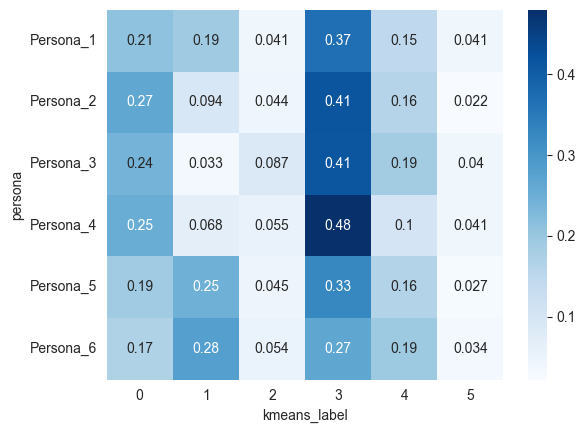

In [38]:
tab = pd.crosstab(selected_features['persona'], selected_features['kmeans_label'], normalize='index')
sns.heatmap(tab, annot=True, cmap='Blues')

<Axes: xlabel='kmeans_label', ylabel='persona'>

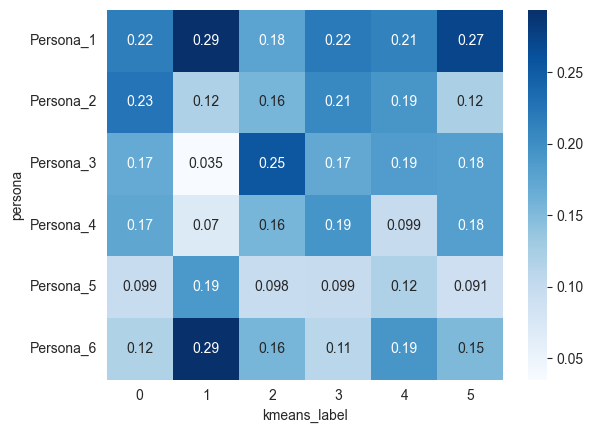

In [39]:
tab = pd.crosstab(selected_features['persona'], selected_features['kmeans_label'], normalize='columns')
sns.heatmap(tab, annot=True, cmap='Blues')

In [40]:
from sklearn.metrics import adjusted_rand_score

adjusted_rand_score(selected_features['persona'], selected_features['kmeans_label'])

0.010561149742616951

**Value close to 0 means random** - There is essentially no alignment between old personas and new clusters. Even though agents were assigned personas, their network position and activity patterns evolved independently.

The Adjusted Rand Index close to zero and the lack of structure in the contingency tables indicate that the clustering results are statistically independent from the predefined personas. This suggests that the original persona assignment does not meaningfully explain differences in structural position, activity, or interaction behavior within the network. Instead, the observed behavioral patterns appear to emerge from the dynamics of the system rather than from the imposed persona categories.

personas = top-down design

clusters = bottom-up emergence

Result shows:

bottom-up structure dominates

#### Hierarchical clustering

KMeans forces spherical clusters. Hierarchical clustering lets structure emerge naturally. It’s often much more interpretable for this kind of data.

In [41]:
from sklearn.cluster import AgglomerativeClustering

model = AgglomerativeClustering(
    n_clusters=6,          # same as KMeans for comparison
    linkage='ward'         # best default
    # linkage='average'   # more flexible
    # linkage='complete'  # tighter clusters
)

labels = model.fit_predict(features_scaled)

selected_features['hier_label'] = labels

C:\Users\magda\AppData\Local\Temp\ipykernel_26484\4108123100.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_features['hier_label'] = labels


In [42]:
selected_features['hier_label'].value_counts()

hier_label
0    560
5    135
3     89
2     82
4     49
1     39
Name: count, dtype: int64

In [43]:
selected_features.drop(columns=['persona', 'kmeans_label'], inplace=False).groupby('hier_label').mean()

,in_out_degree_ratio,betweenness,kcore,neutral_posts_ratio,negative_posts_ratio,posts_per_day,lifespan_median,survival_rate,avg_word_count
hier_label,,,,,,,,,
0,0.760578,0.000258,9.871429,0.028232,0.089411,0.520111,0.006473,0.999485,30.242089
1,1.025226,0.002493,33.820513,0.068426,0.146100,1.740966,17.251603,0.949696,26.951508
2,0.983208,0.000704,16.121951,0.044236,0.109621,0.862529,0.326982,0.866550,29.302890
3,0.626429,0.000336,12.011236,0.147876,0.166912,0.659417,0.027622,0.993440,25.442809
4,1.072230,0.017094,41.000000,0.061597,0.098425,2.993978,5.707908,0.922594,25.735202
5,0.964301,0.003221,35.466667,0.056279,0.109960,1.796032,1.126080,0.962476,26.973116


New clusters:

- Cluster 0 — Passive & extremely stable (“lurkers”) - Users that barely engage but almost never churn
- Cluster 1 — Elite hubs / dominant actors - Highly central, very active, but unstable
- Cluster 2 — Core balanced users - Healthy, stable core of the network
- Cluster 3 — Emotionally distinct / low-structure users - Low-activity, low-structure, but content-distinct group, only cluster clearly separated by content (not structure)

Hierarchical clustering reveals a more nuanced structure than KMeans by separating low-activity users into distinct subgroups based on content characteristics.

<Axes: xlabel='hier_label', ylabel='persona'>

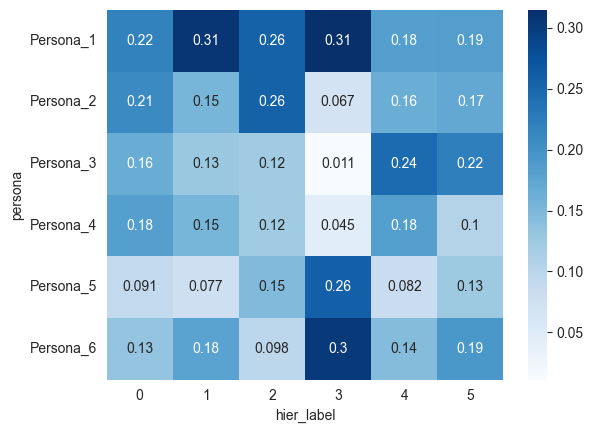

In [44]:
tab = pd.crosstab(selected_features['persona'], selected_features['hier_label'], normalize='columns')
sns.heatmap(tab, annot=True, cmap='Blues')

As before it's random mixing.

<Axes: xlabel='hier_label', ylabel='kmeans_label'>

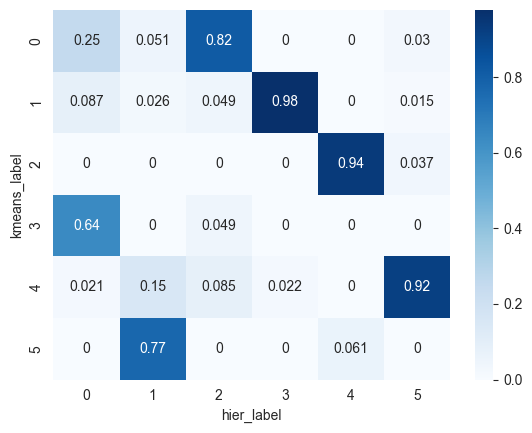

In [45]:
tab = pd.crosstab(selected_features['kmeans_label'], selected_features['hier_label'], normalize='columns')
sns.heatmap(tab, annot=True, cmap='Blues')

In [46]:
print(f"Adjusted rand score:\nold persona vs. hierarchical clustering: {adjusted_rand_score(selected_features['persona'], selected_features['hier_label'])}")
print(f"KMeans vs. hierarchical clustering: {adjusted_rand_score(selected_features['kmeans_label'], selected_features['hier_label'])}")

Adjusted rand score:
old persona vs. hierarchical clustering: 0.009498831611692229
KMeans vs. hierarchical clustering: 0.47348158644668903


There are some relations across new labels. Hierarchical clustering captures some similar structure as KMeans, but refines it differently.

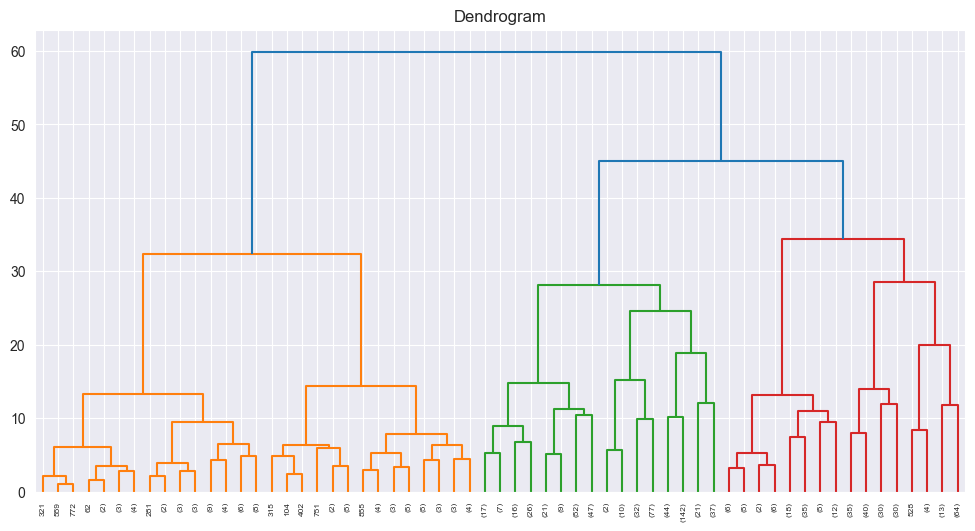

In [47]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

Z = linkage(features_scaled, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode='level', p=5)
plt.title("Dendrogram")
plt.show()

Choosing number of clusters - cut by distance threshold

In [48]:
from scipy.cluster.hierarchy import fcluster

clusters = fcluster(Z, t=20, criterion='distance')
selected_features['hier_cluster'] = clusters

selected_features['hier_cluster'].value_counts()

C:\Users\magda\AppData\Local\Temp\ipykernel_26484\1279447590.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_features['hier_cluster'] = clusters


hier_cluster
5    244
3    195
7    135
4    121
6     89
8     82
1     49
2     39
Name: count, dtype: int64

It's too much group.